# Inference Latency Comparison (Dynamic DeepHit Models)

This notebook benchmarks forward-pass inference latency for four model families:
- GRU
- GRU + Transformer
- Transformer
- Mamba

It reports mean/std/p50/p90 latency and throughput across batch sizes.

In [1]:
from __future__ import annotations

import math
import statistics
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

SEED = 4718
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

Device: cuda
GPU: Tesla V100-SXM2-32GB


In [2]:
import importlib
import os
import shutil
import sys

from src.notebook_setup import (
    cleanup_stale_torch,
    compiler_works,
    gcc_major,
    load_module_env,
    module_exists,
    purge_invalid_wheels,
    run,
    try_download_causal_wheel,
    wheelhouse_has,
)

BASE_CACHE = (
    os.environ.get("SCRATCH")
    or os.environ.get("LOCAL_SCRATCH")
    or "/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa"
)
PIP_CACHE_DIR = os.path.join(BASE_CACHE, ".pip-cache")
WHEEL_DIR = os.path.join(BASE_CACHE, ".wheelhouse", "mamba-ssm")
PKG_DIR = os.path.join(BASE_CACHE, ".py-packages")
os.makedirs(PIP_CACHE_DIR, exist_ok=True)
os.makedirs(WHEEL_DIR, exist_ok=True)
os.makedirs(PKG_DIR, exist_ok=True)

# Keep scratch packages available, but after conda site-packages so conda torch is preferred.
if PKG_DIR in sys.path:
    sys.path.remove(PKG_DIR)
sys.path.append(PKG_DIR)

MAMBA_REQ = "mamba-ssm>=2.2.4"

cleanup_stale_torch(PKG_DIR)

if not shutil.which("nvcc"):
    for cuda_module in ["cuda/12.8", "cuda/12.6", "cuda/12.4", "cuda"]:
        if load_module_env(cuda_module) and shutil.which("nvcc"):
            break
nvcc_path = shutil.which("nvcc")
print("CUDA:", nvcc_path if nvcc_path else "not found")

gpp_path = shutil.which("g++")
if not (gpp_path and gcc_major(gpp_path) >= 9 and compiler_works(gpp_path)):
    gpp_path = None

if not gpp_path:
    for gcc_module in [
        "gcc/13.2.1-p20240113",
        "gcc/10.2.0",
        "gcc/13.3.1-p20240614",
        "gcc",
        "gcc/13",
        "gcc/12",
        "gcc/11",
        "gnu/12",
        "gnu/11",
    ]:
        if load_module_env(gcc_module):
            cand = shutil.which("g++")
            if cand and gcc_major(cand) >= 9 and compiler_works(cand):
                gpp_path = cand
                print(f"Selected compiler from module {gcc_module}")
                break

print("g++:", f"{gpp_path} (major {gcc_major(gpp_path)})" if gpp_path else "not usable")

py_ok = (3, 10) <= sys.version_info[:2] <= (3, 12)
if not py_ok:
    print("mamba-ssm installation skipped; Python version unsupported for this build path.")
else:
    run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel", "ninja"])
    run([sys.executable, "-m", "pip", "install", "--upgrade", "--target", PKG_DIR, "numpy"])
    run([sys.executable, "-m", "pip", "install", "--upgrade", "--target", PKG_DIR, "einops>=0.7"])
    run([sys.executable, "-m", "pip", "install", "--upgrade", "--target", PKG_DIR, "huggingface_hub>=1.0"])
    run([sys.executable, "-m", "pip", "install", "--upgrade", "--target", PKG_DIR, "transformers>=4.45"])
    if not module_exists("causal_conv1d"):
        purge_invalid_wheels(WHEEL_DIR, "causal-conv1d")
        try_download_causal_wheel(WHEEL_DIR)
        if wheelhouse_has(WHEEL_DIR, "causal-conv1d"):
            run([
                sys.executable, "-m", "pip", "install",
                "--no-index",
                "--find-links", WHEEL_DIR,
                "--upgrade",
                "--target", PKG_DIR,
                "--no-deps",
                "causal-conv1d",
            ])
        else:
            print("causal-conv1d wheel unavailable; trying forced source build.")
            cenv = os.environ.copy()
            cenv["PYTHONHTTPSVERIFY"] = "0"
            cenv["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
            cenv["CAUSAL_CONV1D_FORCE_BUILD"] = "TRUE"
            if gpp_path:
                cenv["CXX"] = gpp_path
                cc_guess = gpp_path.replace("g++", "gcc")
                if os.path.exists(cc_guess):
                    cenv["CC"] = cc_guess
            try:
                run([
                    sys.executable, "-m", "pip", "wheel",
                    "--no-build-isolation",
                    "--cache-dir", PIP_CACHE_DIR,
                    "--wheel-dir", WHEEL_DIR,
                    "--trusted-host", "pypi.org",
                    "--trusted-host", "files.pythonhosted.org",
                    "--trusted-host", "github.com",
                    "--trusted-host", "raw.githubusercontent.com",
                    "causal-conv1d>=1.4.0",
                ], env=cenv)
                purge_invalid_wheels(WHEEL_DIR, "causal-conv1d")
                if wheelhouse_has(WHEEL_DIR, "causal-conv1d"):
                    run([
                        sys.executable, "-m", "pip", "install",
                        "--no-index",
                        "--find-links", WHEEL_DIR,
                        "--upgrade",
                        "--target", PKG_DIR,
                        "--no-deps",
                        "causal-conv1d",
                    ])
            except Exception as exc:
                print("Forced source build for causal-conv1d failed:", exc)

    binary_ok = False
    try:
        run([
            sys.executable, "-m", "pip", "install",
            "--cache-dir", PIP_CACHE_DIR,
            "--prefer-binary",
            "--only-binary=:all:",
            "--no-deps",
            "--upgrade",
            "--target", PKG_DIR,
            MAMBA_REQ,
        ])
        binary_ok = True
        print("Installed mamba-ssm wheel successfully.")
    except Exception as exc:
        print("mamba-ssm wheel-only install failed; trying source build fallback.")
        print(exc)

    if not binary_ok and not wheelhouse_has(WHEEL_DIR, "mamba-ssm"):
        build_env = os.environ.copy()
        build_env["MAX_JOBS"] = str(max(1, (os.cpu_count() or 4) // 2))
        build_env["MAMBA_FORCE_BUILD"] = "TRUE"
        build_env["PYTHONHTTPSVERIFY"] = "0"
        build_env["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

        if gpp_path:
            build_env["CXX"] = gpp_path
            cc_guess = gpp_path.replace("g++", "gcc")
            if os.path.exists(cc_guess):
                build_env["CC"] = cc_guess

        run([
            sys.executable, "-m", "pip", "wheel",
            "--no-build-isolation",
            "--cache-dir", PIP_CACHE_DIR,
            "--wheel-dir", WHEEL_DIR,
            "--trusted-host", "pypi.org",
            "--trusted-host", "files.pythonhosted.org",
            "--trusted-host", "github.com",
            "--trusted-host", "raw.githubusercontent.com",
            MAMBA_REQ,
        ], env=build_env)

    if wheelhouse_has(WHEEL_DIR, "mamba-ssm") and not module_exists("mamba_ssm"):
        run([
            sys.executable, "-m", "pip", "install",
            "--no-index",
            "--find-links", WHEEL_DIR,
            "--upgrade",
            "--no-deps",
            "--target", PKG_DIR,
            "mamba-ssm",
        ])

cleanup_stale_torch(PKG_DIR)

if module_exists("causal_conv1d") and module_exists("mamba_ssm"):
    causal_conv1d = importlib.import_module("causal_conv1d")
    mamba_ssm = importlib.import_module("mamba_ssm")

    print("Install complete.")
    print("causal_conv1d:", getattr(causal_conv1d, "__version__", "unknown"))
    print("mamba_ssm:", getattr(mamba_ssm, "__version__", "unknown"))
else:
    print("Install not completed in this kernel.")
    if not module_exists("causal_conv1d"):
        print("causal_conv1d is missing.")
    if not module_exists("mamba_ssm"):
        print("mamba_ssm is missing.")
    print("Try a clean module stack before rerunning Cell 4:")
    print("  module purge && module load gcc/13.2.1-p20240113 cuda/12.6")

print("Package dir:", PKG_DIR)
print("PIP cache:", PIP_CACHE_DIR)
print("Wheelhouse:", WHEEL_DIR)
print("Python:", sys.executable)

CUDA: /opt/packages/cuda/v12.6.1/bin/nvcc
Selected compiler from module gcc/13.2.1-p20240113
g++: /opt/packages/gcc/v13.2.1-p20240113/b2gpu/bin/g++ (major 13)
> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --upgrade pip setuptools wheel ninja
> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --upgrade --target /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages numpy
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --upgrade --target /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages einops>=0.7
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)
> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --upgrade --target /ocean/projects/cis2

ERROR: Could not find a version that satisfies the requirement mamba-ssm>=2.2.4 (from versions: none)
ERROR: No matching distribution found for mamba-ssm>=2.2.4


mamba-ssm wheel-only install failed; trying source build fallback.
Command '['/jet/home/ccheung1/.conda/envs/lob/bin/python3.11', '-m', 'pip', 'install', '--cache-dir', '/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.pip-cache', '--prefer-binary', '--only-binary=:all:', '--no-deps', '--upgrade', '--target', '/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages', 'mamba-ssm>=2.2.4']' returned non-zero exit status 1.


/jet/home/ccheung1/.conda/envs/lob/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Install complete.
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Package dir: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages
PIP cache: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.pip-cache
Wheelhouse: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.wheelhouse/mamba-ssm
Python: /jet/home/ccheung1/.conda/envs/lob/bin/python3.11


In [3]:
# Verify install status only. Use Cell 3 for installation/retry logic.
import os
import sys

from src.notebook_setup import module_exists

BASE_CACHE = (
    os.environ.get("SCRATCH")
    or os.environ.get("LOCAL_SCRATCH")
    or "/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa"
)
PKG_DIR = os.path.join(BASE_CACHE, ".py-packages")
if PKG_DIR not in sys.path:
    sys.path.insert(0, PKG_DIR)

have_causal = module_exists("causal_conv1d")
have_mamba = module_exists("mamba_ssm")

print("Package dir:", PKG_DIR)
print("Python:", sys.executable)
print("causal_conv1d installed:", have_causal)
print("mamba_ssm installed:", have_mamba)

if not (have_causal and have_mamba):
    print("Run Cell 3 to install mamba dependencies.")
else:
    import causal_conv1d
    import mamba_ssm

    print("causal_conv1d:", getattr(causal_conv1d, "__version__", "unknown"))
    print("mamba_ssm:", getattr(mamba_ssm, "__version__", "unknown"))

# Always reload model modules after dependency setup so Mamba import state is fresh.
for mod_name in list(sys.modules):
    if mod_name == "src.models" or mod_name.startswith("src.models."):
        del sys.modules[mod_name]

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
)

print("Model modules loaded/reloaded successfully.")

Package dir: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages
Python: /jet/home/ccheung1/.conda/envs/lob/bin/python3.11
causal_conv1d installed: True
mamba_ssm installed: True
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Model modules loaded/reloaded successfully.


In [20]:
# Match your dynamic setup defaults where possible
NUM_FEATURES = 34
NUM_EVENTS = 2
NUM_TIME_STEPS = 30
SEQ_LEN = 500
DTYPE = torch.float32

BATCH_SIZES = [1, 4, 16, 64, 256]
WARMUP_ITERS = 20
MEASURE_ITERS = 80
USE_AMP = device.type == "cuda"
AMP_DTYPE = torch.float16

@dataclass
class ModelSpec:
    name: str
    builder: callable

MODEL_SPECS = [
    ModelSpec(
        "gru",
        lambda: DeepHitRNNCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=144,
            num_layers=2,
            rnn_dropout=0.2,
            fc_hidden=256,
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "gru_transformer",
        lambda: DeepHitRNNTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=96,
            num_layers=2,
            rnn_dropout=0.2,
            transformer_layers=2,
            transformer_heads=4,
            transformer_ff_dim=192,
            transformer_dropout=0.1,
            max_seq_len=SEQ_LEN,
            fc_hidden=128,
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "transformer",
        lambda: DeepHitTransformerCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=96,
            num_layers=2,
            num_heads=4,
            transformer_ff_dim=320,
            transformer_dropout=0.1,
            max_seq_len=SEQ_LEN,
            fc_hidden=112,
            fc_dropout=0.2,
        ),
    ),
    ModelSpec(
        "mamba",
        lambda: DeepHitMambaCompeting(
            num_features=NUM_FEATURES,
            num_events=NUM_EVENTS,
            num_time_steps=NUM_TIME_STEPS,
            hidden_size=128,
            num_mamba_layers=2,
            d_state=16,
            d_conv=4,
            expand=2,
            mamba_dropout=0.15,
            fc_dropout=0.2,
        ),
    ),
]

In [21]:
def _sync_if_needed() -> None:
    if device.type == "cuda":
        torch.cuda.synchronize()


def benchmark_forward_latency_ms(model: torch.nn.Module, x: torch.Tensor, warmup: int, iters: int) -> list[float]:
    model.eval()
    times_ms: list[float] = []

    with torch.inference_mode():
        for _ in range(warmup):
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                _ = model(x)

        _sync_if_needed()

        if device.type == "cuda":
            starter = torch.cuda.Event(enable_timing=True)
            ender = torch.cuda.Event(enable_timing=True)

            for _ in range(iters):
                starter.record()
                with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                    _ = model(x)
                ender.record()
                torch.cuda.synchronize()
                times_ms.append(starter.elapsed_time(ender))
        else:
            for _ in range(iters):
                t0 = time.perf_counter()
                _ = model(x)
                t1 = time.perf_counter()
                times_ms.append((t1 - t0) * 1000.0)

    return times_ms


def summarize_times(model_name: str, batch_size: int, times_ms: list[float], n_params: int) -> dict:
    p50 = float(np.percentile(times_ms, 50))
    p90 = float(np.percentile(times_ms, 90))
    mean_ms = float(np.mean(times_ms))
    std_ms = float(np.std(times_ms))
    throughput = float(batch_size * 1000.0 / mean_ms) if mean_ms > 0 else math.nan
    return {
        "model": model_name,
        "batch_size": batch_size,
        "n_params": int(n_params),
        "latency_mean_ms": mean_ms,
        "latency_std_ms": std_ms,
        "latency_p50_ms": p50,
        "latency_p90_ms": p90,
        "throughput_samples_per_s": throughput,
        "num_measurements": len(times_ms),
    }

In [22]:
results = []

for spec in MODEL_SPECS:
    print(f"\n=== Benchmarking {spec.name} ===", flush=True)

    try:
        model = spec.builder().to(device)
    except Exception as exc:
        print(f"Skipping {spec.name}: model build failed -> {exc}", flush=True)
        continue

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    for bs in BATCH_SIZES:
        x = torch.randn(bs, SEQ_LEN, NUM_FEATURES, dtype=DTYPE, device=device)

        try:
            times = benchmark_forward_latency_ms(
                model=model,
                x=x,
                warmup=WARMUP_ITERS,
                iters=MEASURE_ITERS,
            )
            row = summarize_times(spec.name, bs, times, n_params)
            results.append(row)
            print(
                f"{spec.name:>16} | bs={bs:>4} | mean={row['latency_mean_ms']:.3f} ms | p90={row['latency_p90_ms']:.3f} ms | "
                f"throughput={row['throughput_samples_per_s']:.1f} samples/s",
                flush=True,
            )
        except RuntimeError as exc:
            if "out of memory" in str(exc).lower() or "cuda oom" in str(exc).lower():
                print(f"{spec.name:>16} | bs={bs:>4} | OOM -> skipping larger measurements for this batch", flush=True)
                if device.type == "cuda":
                    torch.cuda.empty_cache()
            else:
                print(f"{spec.name:>16} | bs={bs:>4} | failed -> {exc}", flush=True)

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values(["batch_size", "latency_mean_ms"]).reset_index(drop=True)

results_df


=== Benchmarking gru ===
             gru | bs=   1 | mean=4.112 ms | p90=4.351 ms | throughput=243.2 samples/s
             gru | bs=   4 | mean=3.920 ms | p90=3.940 ms | throughput=1020.5 samples/s
             gru | bs=  16 | mean=3.520 ms | p90=3.535 ms | throughput=4545.7 samples/s
             gru | bs=  64 | mean=3.928 ms | p90=3.938 ms | throughput=16295.2 samples/s
             gru | bs= 256 | mean=5.316 ms | p90=5.330 ms | throughput=48154.6 samples/s

=== Benchmarking gru_transformer ===
 gru_transformer | bs=   1 | mean=3.172 ms | p90=3.207 ms | throughput=315.2 samples/s
 gru_transformer | bs=   4 | mean=3.262 ms | p90=3.290 ms | throughput=1226.2 samples/s
 gru_transformer | bs=  16 | mean=4.352 ms | p90=4.388 ms | throughput=3676.8 samples/s
 gru_transformer | bs=  64 | mean=6.136 ms | p90=6.150 ms | throughput=10430.1 samples/s
 gru_transformer | bs= 256 | mean=14.962 ms | p90=14.994 ms | throughput=17109.5 samples/s

=== Benchmarking transformer ===
     transformer |

,model,batch_size,n_params,latency_mean_ms,latency_std_ms,latency_p50_ms,latency_p90_ms,throughput_samples_per_s,num_measurements
0,mamba,1,330909,1.988659,0.048105,1.977856,2.066944,502.851366,80
1,transformer,1,304669,2.175872,0.013856,2.170880,2.193613,459.585850,80
2,gru_transformer,1,349917,3.172250,0.024450,3.160064,3.207373,315.233710,80
3,gru,1,345309,4.112013,0.190526,4.013056,4.350976,243.189905,80
4,mamba,4,330909,1.908467,0.039507,1.908736,1.976115,2095.922840,80
5,transformer,4,304669,2.239450,0.057576,2.229760,2.335129,1786.153162,80
6,gru_transformer,4,349917,3.262106,0.028999,3.266048,3.290317,1226.201877,80
7,gru,4,345309,3.919514,0.024171,3.926016,3.940454,1020.534796,80
8,mamba,16,330909,1.887846,0.045109,1.860608,1.974170,8475.265805,80
9,transformer,16,304669,2.285670,0.053979,2.306560,2.342195,7000.134449,80


          model  batch_size  n_params  latency_mean_ms  latency_p50_ms  latency_p90_ms  throughput_samples_per_s
          mamba           1    330909         1.988659        1.977856        2.066944                502.851366
    transformer           1    304669         2.175872        2.170880        2.193613                459.585850
gru_transformer           1    349917         3.172250        3.160064        3.207373                315.233710
            gru           1    345309         4.112013        4.013056        4.350976                243.189905
          mamba           4    330909         1.908467        1.908736        1.976115               2095.922840
    transformer           4    304669         2.239450        2.229760        2.335129               1786.153162
gru_transformer           4    349917         3.262106        3.266048        3.290317               1226.201877
            gru           4    345309         3.919514        3.926016        3.940454          

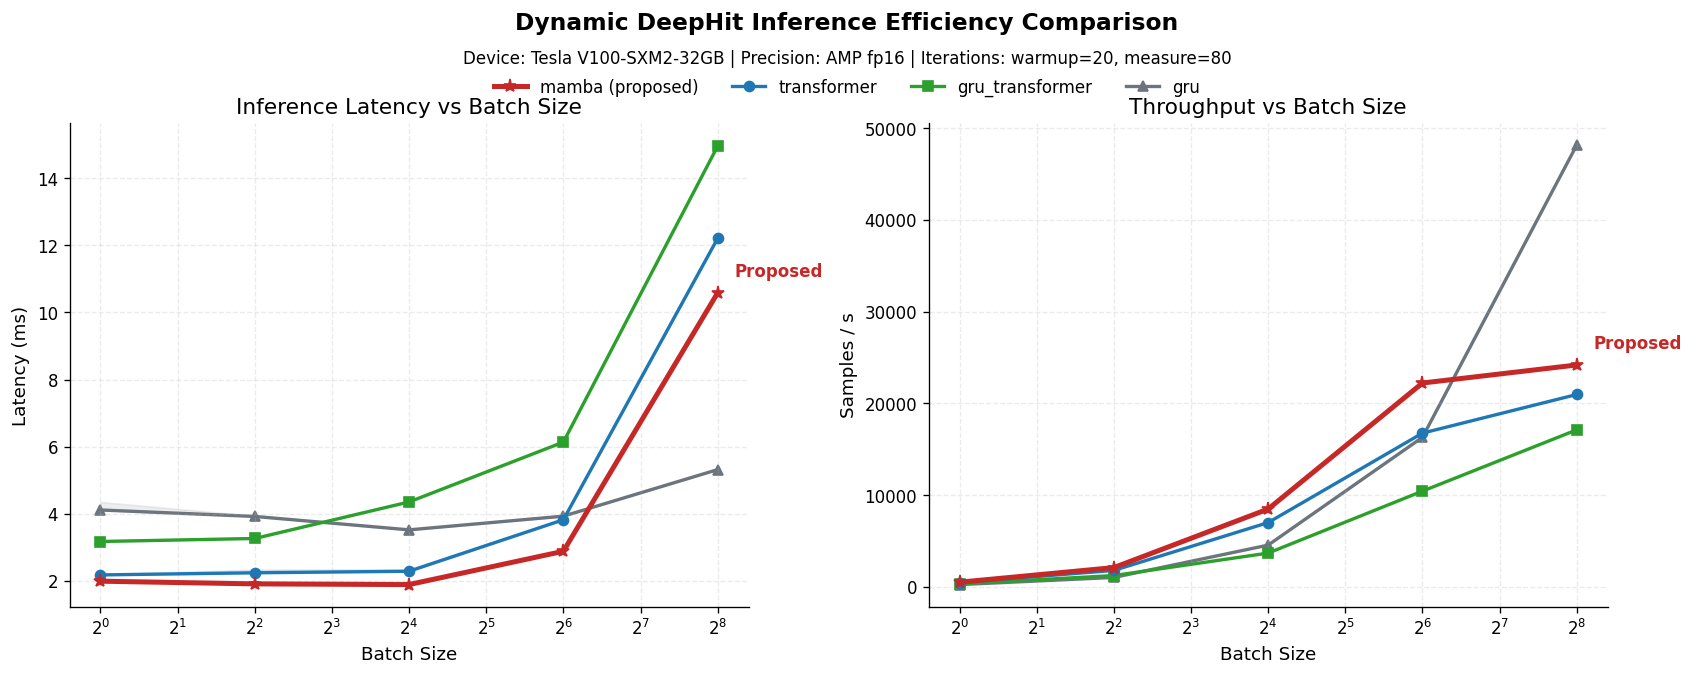

Saved benchmark table to results/inference_latency_comparison.csv
Saved publication figures to results/figures/inference_latency_comparison_publication.png and results/figures/inference_latency_comparison_publication.pdf


In [27]:
if results_df.empty:
    raise RuntimeError("No benchmark results were collected.")

display_cols = [
    "model",
    "batch_size",
    "n_params",
    "latency_mean_ms",
    "latency_p50_ms",
    "latency_p90_ms",
    "throughput_samples_per_s",
]
print(results_df[display_cols].to_string(index=False))

# Paper-ready benchmark metadata
import platform
from datetime import datetime, timezone
from pathlib import Path

param_by_model = (
    results_df[["model", "n_params"]]
    .drop_duplicates(subset=["model"])
    .sort_values("model")
    .set_index("model")["n_params"]
    .to_dict()
)

reported_models = sorted(results_df["model"].unique().tolist())
expected_models = sorted([spec.name for spec in MODEL_SPECS])
missing_models = sorted(list(set(expected_models) - set(reported_models)))

paper_metadata = {
    "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%SZ"),
    "host_platform": platform.platform(),
    "python_version": platform.python_version(),
    "pytorch_version": torch.__version__,
    "device_type": device.type,
    "gpu_name": torch.cuda.get_device_name(0) if device.type == "cuda" else "N/A",
    "cuda_runtime": torch.version.cuda if torch.version.cuda is not None else "N/A",
    "cudnn_version": int(torch.backends.cudnn.version()) if torch.backends.cudnn.version() is not None else "N/A",
    "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
    "seed": int(SEED),
    "input_shape_template": f"(batch, {SEQ_LEN}, {NUM_FEATURES})",
    "num_events": int(NUM_EVENTS),
    "num_time_steps": int(NUM_TIME_STEPS),
    "input_dtype": str(DTYPE),
    "amp_enabled": bool(USE_AMP),
    "amp_dtype": str(AMP_DTYPE),
    "warmup_iterations": int(WARMUP_ITERS),
    "measured_iterations": int(MEASURE_ITERS),
    "batch_sizes": [int(b) for b in BATCH_SIZES],
    "timing_method": "CUDA events + synchronize" if device.type == "cuda" else "time.perf_counter",
    "inference_mode": True,
    "models_benchmarked": reported_models,
    "models_missing": missing_models,
    "model_parameters": {k: int(v) for k, v in param_by_model.items()},
}

print("\n" + "=" * 90)
print("PAPER REPORTING METADATA (copy into Methods / Experimental Setup)")
print("=" * 90)
for key, value in paper_metadata.items():
    print(f"{key:<22}: {value}")
print("=" * 90)

if "have_mamba" in globals() and "have_causal" in globals():
    print(f"Dependency status -> causal_conv1d={have_causal}, mamba_ssm={have_mamba}")

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    }
)

color_map = {
    "mamba": "#C62828",          # proposed method highlight
    "transformer": "#1F77B4",
    "gru_transformer": "#2CA02C",
    "gru": "#6C757D",
}

marker_map = {
    "mamba": "*",
    "transformer": "o",
    "gru_transformer": "s",
    "gru": "^",
}

line_width_map = {
    "mamba": 3.0,
    "transformer": 2.0,
    "gru_transformer": 2.0,
    "gru": 2.0,
}

zorder_map = {
    "mamba": 5,
    "transformer": 3,
    "gru_transformer": 2,
    "gru": 1,
}

# Put mamba first in legend/order if present
plot_order = [m for m in ["mamba", "transformer", "gru_transformer", "gru"] if m in results_df["model"].unique()]
other_models = sorted([m for m in results_df["model"].unique() if m not in plot_order])
plot_order.extend(other_models)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

for model_name in plot_order:
    grp = results_df[results_df["model"] == model_name].sort_values("batch_size")
    color = color_map.get(model_name, "#444444")
    marker = marker_map.get(model_name, "o")
    lw = line_width_map.get(model_name, 2.0)
    zo = zorder_map.get(model_name, 1)

    mean_latency = grp["latency_mean_ms"].to_numpy()
    p90_latency = grp["latency_p90_ms"].to_numpy()
    throughput = grp["throughput_samples_per_s"].to_numpy()
    bs = grp["batch_size"].to_numpy()

    label = "mamba (proposed)" if model_name == "mamba" else model_name

    axes[0].plot(
        bs,
        mean_latency,
        marker=marker,
        linewidth=lw,
        color=color,
        markersize=8 if model_name == "mamba" else 6,
        label=label,
        zorder=zo,
    )
    # Show variability tail with p90 band
    axes[0].fill_between(bs, mean_latency, p90_latency, color=color, alpha=0.12, zorder=max(0, zo - 1))

    axes[1].plot(
        bs,
        throughput,
        marker=marker,
        linewidth=lw,
        color=color,
        markersize=8 if model_name == "mamba" else 6,
        label=label,
        zorder=zo,
    )

    if model_name == "mamba" and len(bs) > 0:
        axes[0].annotate(
            "Proposed",
            xy=(bs[-1], mean_latency[-1]),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=10,
            color=color,
            fontweight="bold",
        )
        axes[1].annotate(
            "Proposed",
            xy=(bs[-1], throughput[-1]),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=10,
            color=color,
            fontweight="bold",
        )

axes[0].set_title("Inference Latency vs Batch Size")
axes[0].set_xlabel("Batch Size")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_xscale("log", base=2)
axes[0].grid(alpha=0.25, linestyle="--", linewidth=0.8)

axes[1].set_title("Throughput vs Batch Size")
axes[1].set_xlabel("Batch Size")
axes[1].set_ylabel("Samples / s")
axes[1].set_xscale("log", base=2)
axes[1].grid(alpha=0.25, linestyle="--", linewidth=0.8)

# Shared legend centered above panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.05))

fig.suptitle("Dynamic DeepHit Inference Efficiency Comparison", fontsize=14, fontweight="bold", y=1.14)
fig.text(
    0.5,
    1.05,
    f"Device: {paper_metadata['gpu_name']} | Precision: {'AMP fp16' if USE_AMP else 'fp32'} | Iterations: warmup={WARMUP_ITERS}, measure={MEASURE_ITERS}",
    ha="center",
    fontsize=10,
)

plt.show()

out_csv = "results/latency_comparison.csv"
results_df.to_csv(out_csv, index=False)
print(f"Saved benchmark table to {out_csv}")

fig_dir = Path("results") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
png_path = fig_dir / "latency.png"
pdf_path = fig_dir / "latency.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved figures to {png_path} and {pdf_path}")